# 0.0 Import


In [79]:
import math
import numpy as np
import pandas as pd
import random
import pickle
import warnings
import inflection
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import warnings


from sklearn.ensemble      import RandomForestRegressor
from boruta                import BorutaPy
from sklearn.ensemble      import ExtraTreesClassifier
from matplotlib            import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier

from sklearn import model_selection as ms
from sklearn import preprocessing   as pp
from sklearn import ensemble        as en
from sklearn import neighbors       as nh


warnings.filterwarnings("ignore")

In [80]:
df_raw = pd.read_csv(r'C:\Users\miks-\OneDrive\Área de Trabalho\Estudos\Churn\Original.csv')
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 1.0 Descrição dos Dados

In [81]:
df = df_raw.copy()

## 1.1 Data Dimensions

In [82]:
print('Number of Rows: {}'.format( df.shape[0]))
print('Number of Rows: {}'.format( df.shape[1]))

Number of Rows: 7043
Number of Rows: 21


## 1.2 Columns Rename

In [83]:
# Rename Columns
cols_old =  ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents','tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

snakecase = lambda x: inflection.underscore( x )

cols_new = list( map( snakecase, cols_old ) )

# rename
df.columns = cols_new

In [84]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1.3 Data Types

In [85]:
# Data Types
df['total_charges'] = df['total_charges'].replace(' ', 0).astype(float)
df.dtypes

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object

## 1.4 Check NA

In [86]:
# Isnull
df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

## 1.5 Descritive Statistic

In [87]:
num_attributes = df.select_dtypes( include=['int64','float64'])
cat_attributes = df.select_dtypes( exclude=['int64','float64'])

In [88]:
#Numerical Atributes
# Central Tendency- mean, meadina
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# dispersion- std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( min ) ).T
d3 = pd.DataFrame( num_attributes.apply( max ) ).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max()- x.min() ) ).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# concatenar
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std','skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,senior_citizen,0.00,1.00,1.0,0.162147,0.00,0.368585,1.833633,1.362596
1,tenure,0.00,72.00,72.0,32.371149,29.00,24.557737,0.239540,-1.387372
2,monthly_charges,18.25,118.75,100.5,64.761692,70.35,30.087911,-0.220524,-1.257260
3,total_charges,0.00,8684.80,8684.8,2279.734304,1394.55,2266.633539,0.963235,-0.228580


# 2.0 Feature Enginner

In [89]:
df1 = df.copy()

## 2.1 Feature Creator

In [90]:
# Life Value Mean
df1['lf_value'] = df1['monthly_charges'] / df1['total_charges'] 
df1.head()



,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,lf_value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1.000000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0.030140
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.497920
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0.022980
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0.466205


# 3.0 EDA

In [91]:
df2 = df1.copy()

In [92]:
df2.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,lf_value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1.000000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0.030140
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.497920
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0.022980
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0.466205


## 3.1 Analise Univariavel

## 3.2 Analise Bivariavel 

### **H1.** Churn por Gênero
**Pergunta** Verificar se existe alguma relação da Feature de Gênero com o Churn

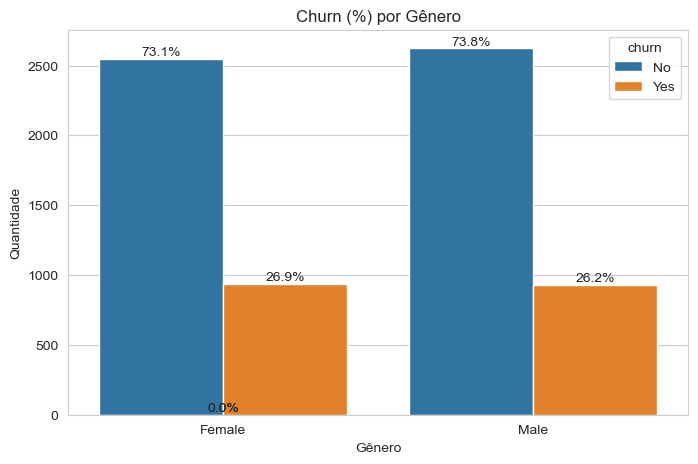

In [93]:
#  3.1 Um Gênero sobresai sobre o outro em questão do Churn

plt.figure(figsize=(8,5))

ax = sns.countplot(x='gender', hue='churn', data=df)

# Total por gênero (para calcular %)
totais = df['gender'].value_counts()

# Adicionando porcentagem
for p in ax.patches:
    height = p.get_height()
    genero = p.get_x() + p.get_width() / 2.

# Loop correto com índice
for i, p in enumerate(ax.patches):
    height = p.get_height()
    
    # Descobre qual gênero a barra pertence
    genero = df['gender'].unique()[i % len(df['gender'].unique())]
    total = totais[genero]
    
    percentual = 100 * height / total

    ax.annotate(f'{percentual:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.title('Churn (%) por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')

plt.show()

### **H2.** Analise de Churn por Features
**Pergunta** Verificar se alguma Feature chama atenção para o Churn ?

**Verdadeiro** Fibra Optic tem a maior representatividade no Churn como o produto mais problematico.

**Verdadeiro** Segurança Online tem a maior representatividade no Churn 

**Verdadeiro** Contratos mais recentes tem maiores chances de virar um Churn.

**Verdadeiro** Meio de Pagamento Cheque Eletronico tem quase a metade do Churn.



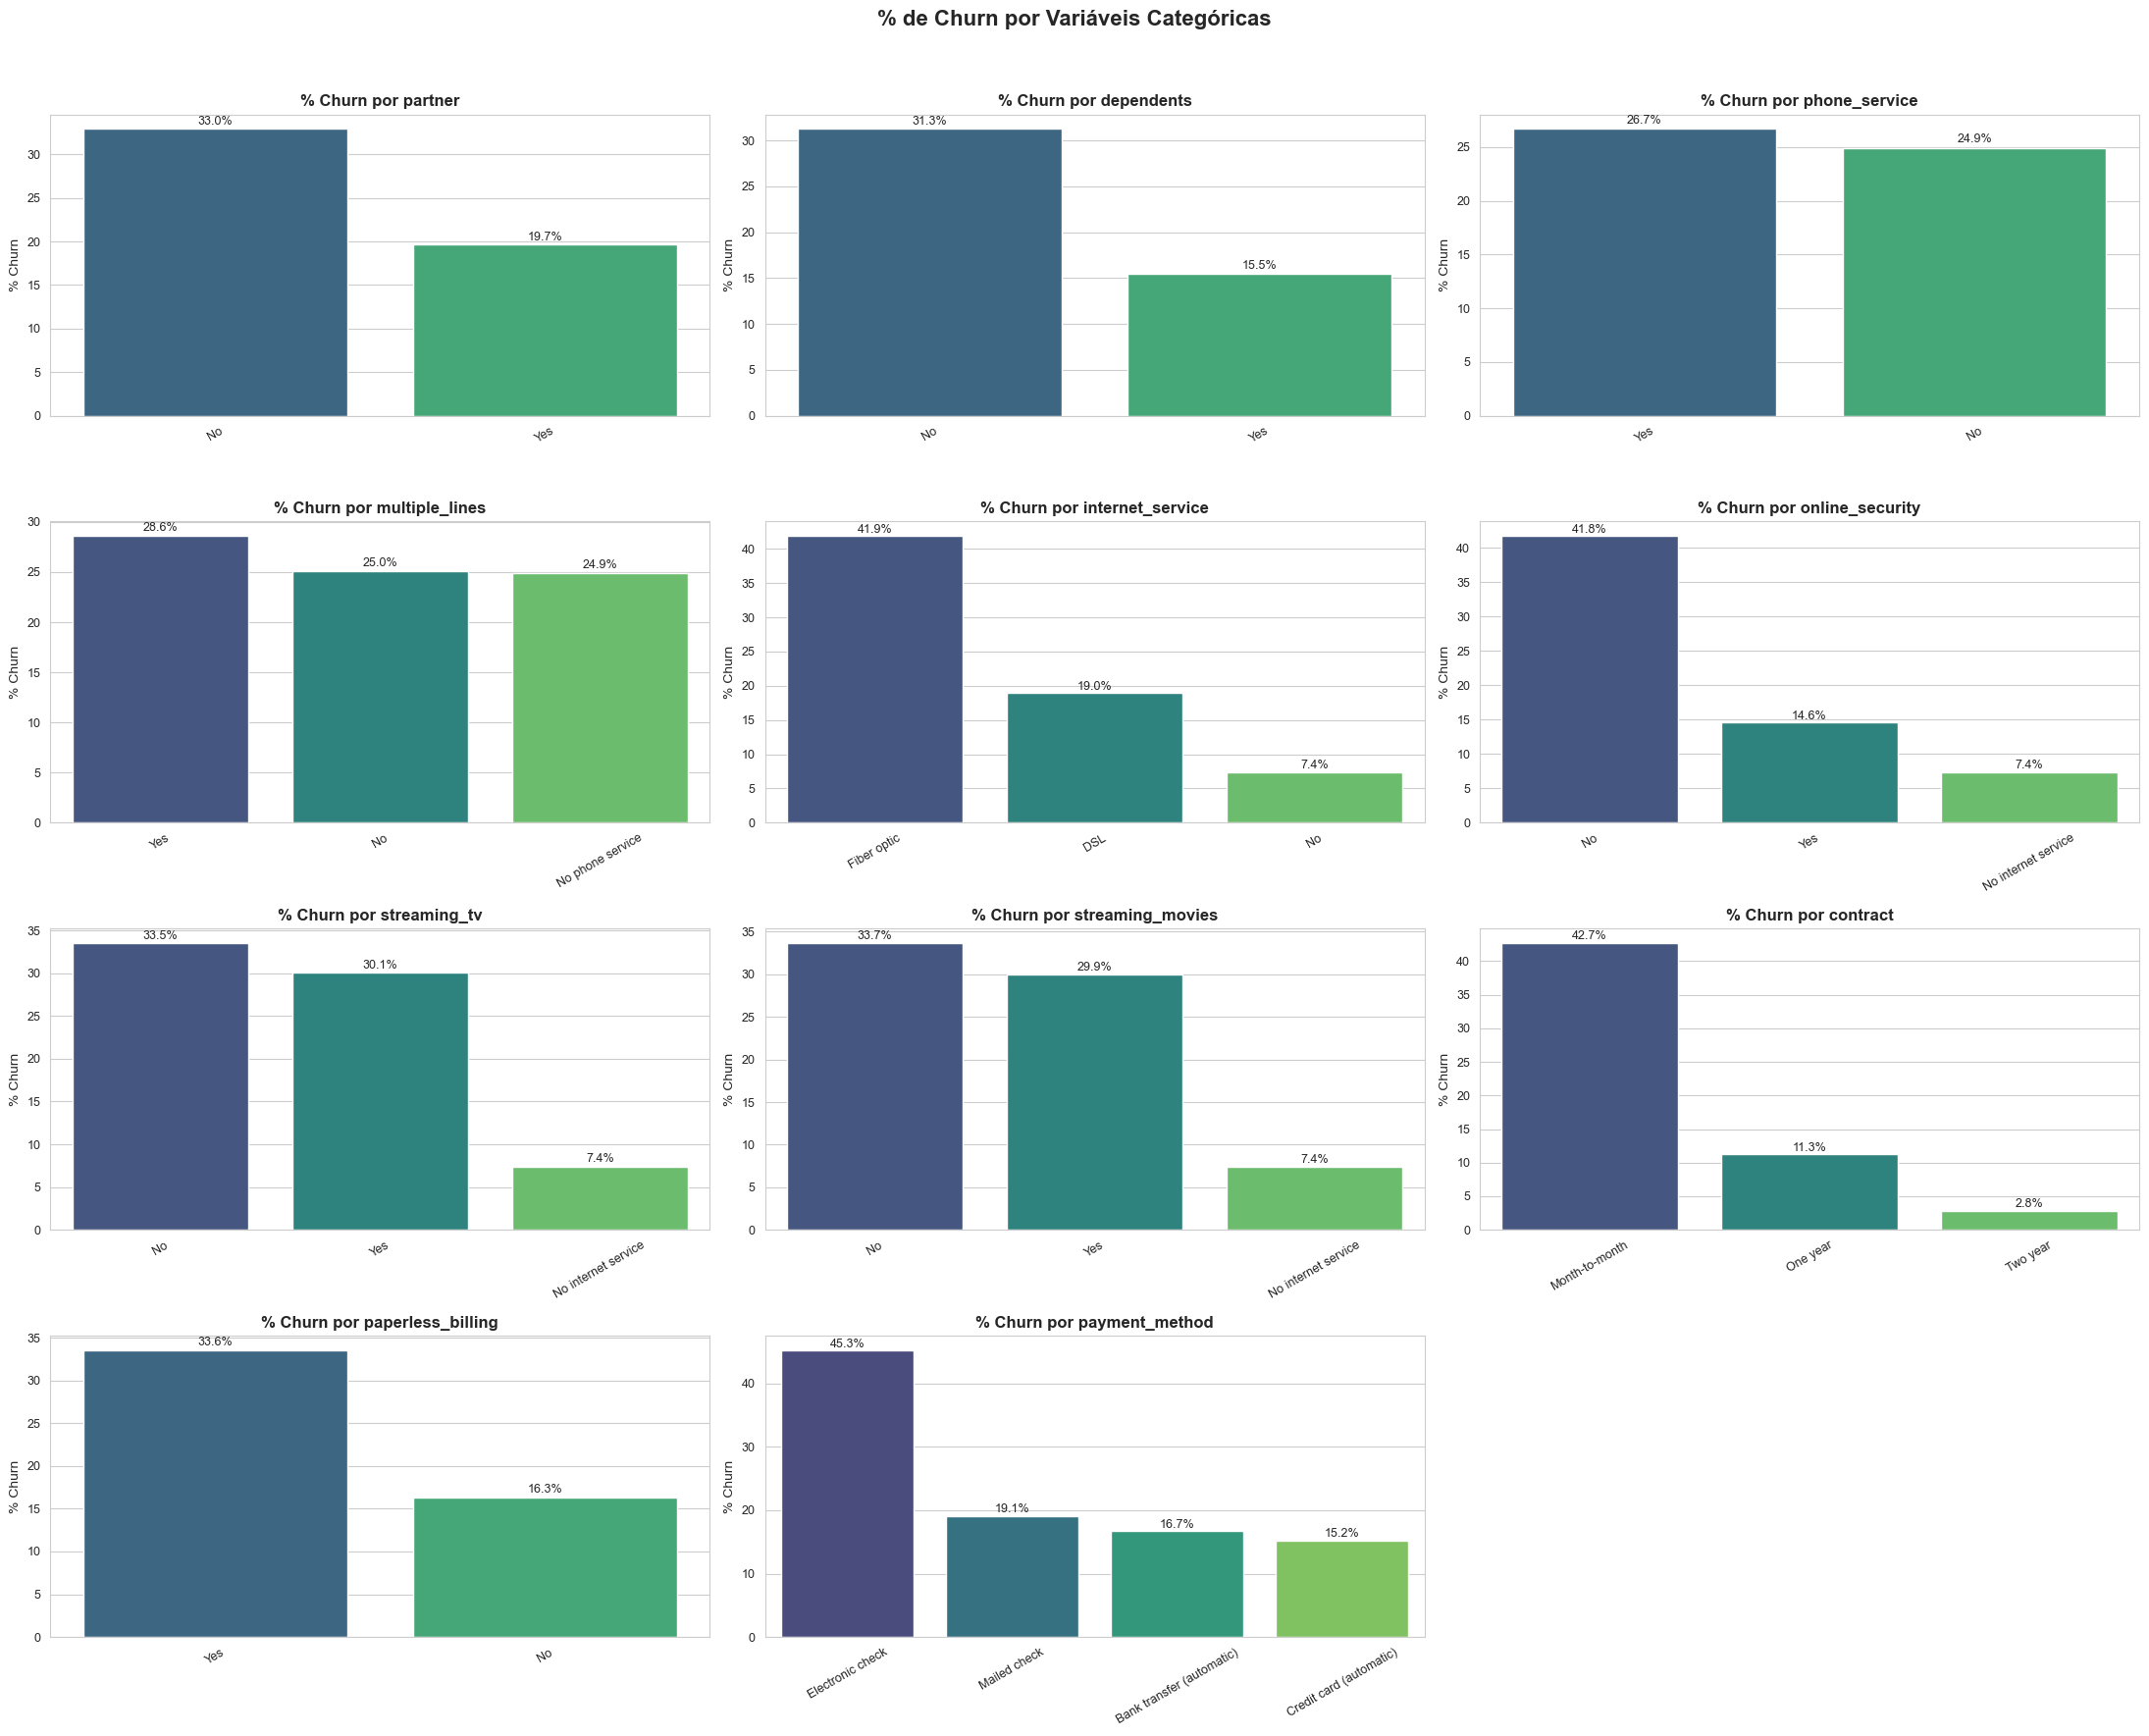

In [94]:
sns.set_style("whitegrid")

cols = [
    'partner', 'dependents', 'phone_service',
    'multiple_lines', 'internet_service', 'online_security',
    'streaming_tv', 'streaming_movies', 'contract',
    'paperless_billing', 'payment_method'
]

# Criar figura maior e mais espaçada
fig, axes = plt.subplots(4, 3, figsize=(22, 18))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    # % churn por categoria
    churn_pct = (
        df.groupby(col)['churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index(name='churn_pct')
    )
    
    # gráfico
    sns.barplot(
        data=churn_pct,
        x=col,
        y='churn_pct',
        ax=axes[i],
        palette='viridis'
    )
    
    axes[i].set_title(f'% Churn por {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% Churn', fontsize=10)
    
    # Rotação melhor controlada
    axes[i].tick_params(axis='x', rotation=30, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

    # valores nas barras
    for j, row in churn_pct.iterrows():
        axes[i].text(
            j,
            row['churn_pct'] + 0.5,
            f"{row['churn_pct']:.1f}%",
            ha='center',
            fontsize=9
        )

# Remover gráficos vazios (caso sobrem espaços)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('% de Churn por Variáveis Categóricas', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

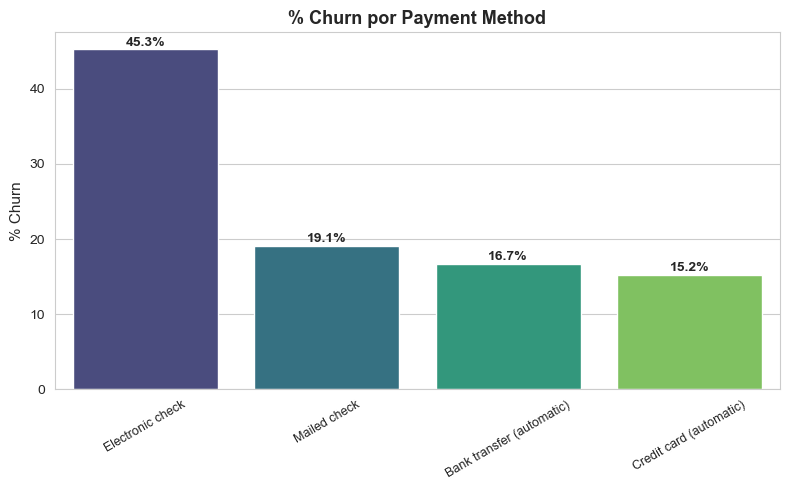

In [134]:
# payment_method
sns.set_style("whitegrid")

churn_pct = (
    df2.groupby('payment_method')['churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='churn_pct')
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=churn_pct, x='payment_method', y='churn_pct', ax=ax, palette='viridis')  # ← churn_pct aqui

ax.set_title('% Churn por Payment Method', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Churn', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)

for j, row in churn_pct.iterrows():
    ax.text(j, row['churn_pct'] + 0.5, f"{row['churn_pct']:.1f}%", ha='center', fontsize=10, fontweight='bold')  # ← churn_pct aqui

plt.tight_layout()
plt.show()

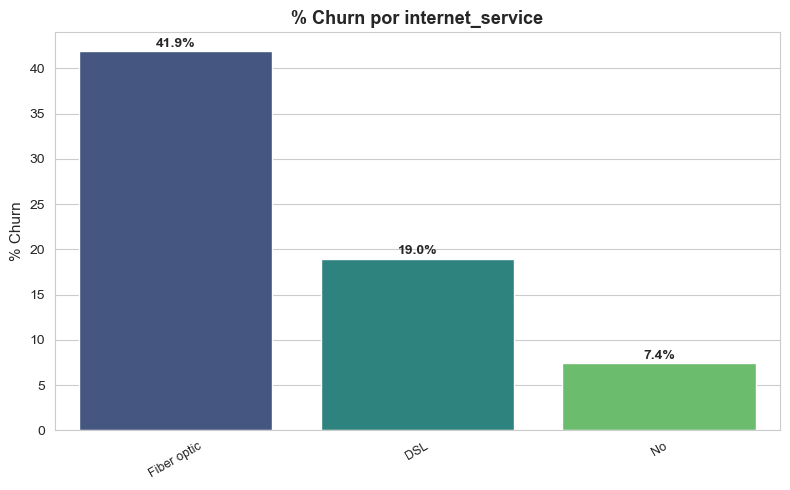

In [135]:
# internet_service
sns.set_style("whitegrid")

churn_pct = (
    df2.groupby('internet_service')['churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='churn_pct')
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=churn_pct, x='internet_service', y='churn_pct', ax=ax, palette='viridis')  # ← churn_pct aqui

ax.set_title('% Churn por internet_service', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Churn', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)

for j, row in churn_pct.iterrows():
    ax.text(j, row['churn_pct'] + 0.5, f"{row['churn_pct']:.1f}%", ha='center', fontsize=10, fontweight='bold')  # ← churn_pct aqui

plt.tight_layout()
plt.show()

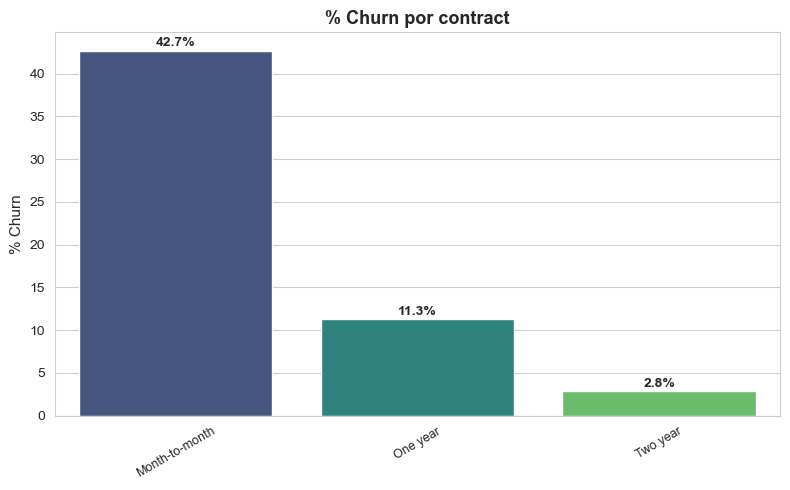

In [137]:
# contract
sns.set_style("whitegrid")

churn_pct = (
    df2.groupby('contract')['churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='churn_pct')
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=churn_pct, x='contract', y='churn_pct', ax=ax, palette='viridis')  # ← churn_pct aqui

ax.set_title('% Churn por contract', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Churn', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)

for j, row in churn_pct.iterrows():
    ax.text(j, row['churn_pct'] + 0.5, f"{row['churn_pct']:.1f}%", ha='center', fontsize=10, fontweight='bold')  # ← churn_pct aqui

plt.tight_layout()
plt.show()

## 3.3 Analise Multivariavel

<Axes: >

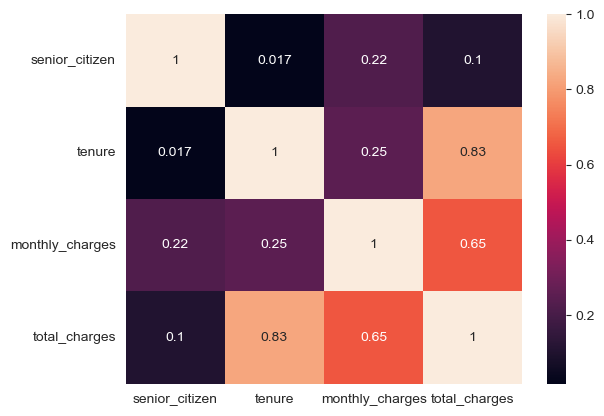

In [95]:
correlation = num_attributes.corr( method='pearson' )
sns.heatmap( correlation, annot=True )

# 4.0 Preparação dos Dados 

In [96]:
df3 = df2.copy()
df3.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,lf_value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1.000000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0.030140
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.497920
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0.022980
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0.466205


## 4.1 Train and Test

In [97]:
X = df3.drop('churn', axis=1)
y = df3['churn'].copy()

x_train, x_validation, y_train, y_validation = ms.train_test_split(X, y, test_size=0.20 )

df4 = pd.concat([x_train,y_train], axis=1)
df4.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,lf_value,churn
6325,4558-FANTW,Female,0,Yes,Yes,17,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,Month-to-month,No,Electronic check,91.85,1574.45,0.058338,Yes
6633,4415-IJZTP,Female,0,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,74.50,74.50,1.000000,Yes
2109,3521-HTQTV,Male,0,No,No,34,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),26.10,980.35,0.026623,No
3093,9931-DCEZH,Male,0,No,Yes,28,Yes,No,DSL,No,...,Yes,No,No,One year,Yes,Credit card (automatic),54.40,1516.60,0.035870,No
6246,7054-DMVAS,Male,0,No,No,54,Yes,No,DSL,Yes,...,No,Yes,No,Two year,Yes,Bank transfer (automatic),65.30,3512.90,0.018589,No


## 4.2 Standardization

In [98]:
#ss = StandardScaler() 
#annual_premium 
#df4['total_charges'] = ss.fit_transform(df4[['total_charges']].values)
#df4['monthly_charges'] = ss.fit_transform(df4[['monthly_charges']].values

## 4.3 Rescaling

In [99]:
mms_age = pp.MinMaxScaler() 

#tenure
df4['tenure'] = mms_age.fit_transform( df4[['tenure']].values )
df4.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,lf_value,churn
6325,4558-FANTW,Female,0,Yes,Yes,0.236111,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,Month-to-month,No,Electronic check,91.85,1574.45,0.058338,Yes
6633,4415-IJZTP,Female,0,No,No,0.013889,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,74.50,74.50,1.000000,Yes
2109,3521-HTQTV,Male,0,No,No,0.472222,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),26.10,980.35,0.026623,No
3093,9931-DCEZH,Male,0,No,Yes,0.388889,Yes,No,DSL,No,...,Yes,No,No,One year,Yes,Credit card (automatic),54.40,1516.60,0.035870,No
6246,7054-DMVAS,Male,0,No,No,0.750000,Yes,No,DSL,Yes,...,No,Yes,No,Two year,Yes,Bank transfer (automatic),65.30,3512.90,0.018589,No


## 4.4 Enconder 

In [100]:
# churn
df4['churn'] = df4['churn'].map({'Yes': 1, 'No': 0})

In [101]:
#gender - Label Enconding
df4['gender'] = df4['gender'].apply( lambda x: 0 if x == 'Male' else 1 )

#partner - Target Enconding
target_encode_partner = df4.groupby('partner')['churn'].mean()
df4['partner'] = df4['partner'].map(target_encode_partner)

# dependents
df4['dependents'] = df4['dependents'].map({'Yes': 1, 'No': 0})

# phone_service
df4['phone_service'] = df4['phone_service'].map({'Yes': 1, 'No': 0})

# multiple_lines
df4['multiple_lines'] = df4['multiple_lines'].map({'Yes': 1, 'No': 0, 'NaN':2})

# internet_service
df4['internet_service'] = df4['internet_service'].map({'Fiber optic': 0, 'DSL': 1, 'No':3})

# online_security
df4['online_security'] = df4['online_security'].map({'No': 0, 'Yes': 1, 'No internet service':3})

# tech_support
df4['tech_support'] = df4['tech_support'].map({'No': 0, 'Yes': 1, 'No internet service':3})

# streaming_tv
df4['streaming_tv'] = df4['streaming_tv'].map({'No': 0, 'Yes': 1, 'No internet service':3})

# streaming_movies
df4['streaming_movies'] = df4['streaming_movies'].map({'No': 0, 'Yes': 1, 'No internet service':3})

# online_backup
df4['online_backup'] = df4['online_backup'].map({'No': 0, 'Yes': 1, 'No internet service':3})

# device_protection
df4['device_protection'] = df4['device_protection'].map({'No': 0, 'Yes': 1, 'No internet service':3})

# contract - Target Enconding
target_encode_contract = df4.groupby('contract')['churn'].mean()
df4['contract'] = df4['contract'].map(target_encode_contract)

# paperless_billing
df4['paperless_billing'] = df4['paperless_billing'].map({'Yes': 1, 'No': 0})

# payment_method - Target Enconding
target_encode_payment_method = df4.groupby('payment_method')['churn'].mean()
df4['payment_method'] = df4['payment_method'].map(target_encode_payment_method)
df4.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,lf_value,churn
6325,4558-FANTW,1,0,0.197517,1,0.236111,1,0.0,0,1,...,1,1,0,0.425065,0,0.457464,91.85,1574.45,0.058338,1
6633,4415-IJZTP,1,0,0.328843,0,0.013889,1,1.0,0,0,...,0,0,0,0.425065,1,0.457464,74.50,74.50,1.000000,1
2109,3521-HTQTV,0,0,0.328843,0,0.472222,1,1.0,3,3,...,3,3,3,0.030125,0,0.165160,26.10,980.35,0.026623,0
3093,9931-DCEZH,0,0,0.328843,1,0.388889,1,0.0,1,0,...,1,0,0,0.115548,1,0.148539,54.40,1516.60,0.035870,0
6246,7054-DMVAS,0,0,0.328843,0,0.750000,1,0.0,1,1,...,0,1,0,0.030125,1,0.165160,65.30,3512.90,0.018589,0


# 5.0 Seleção de Features

## 5.1 Feature Importancia

In [102]:
forest = en.ExtraTreesClassifier( n_estimators=250, random_state=0, n_jobs=-1)

#data preparation
x_train_n = df4.drop(['customer_id','churn','lf_value'], axis=1)
y_train_n = y_train.values

#model
forest.fit( x_train_n, y_train_n )

ExtraTreesClassifier(n_estimators=250, n_jobs=-1, random_state=0)

Feature ranking:
             feature  importance
0      total_charges    0.151388
0             tenure    0.143583
0    monthly_charges    0.130705
0           contract    0.085825
0     payment_method    0.072889
0             gender    0.038289
0    online_security    0.037626
0       tech_support    0.037121
0   internet_service    0.036871
0      online_backup    0.032944
0            partner    0.031681
0  device_protection    0.031067
0  paperless_billing    0.029934
0   streaming_movies    0.029497
0       streaming_tv    0.027945
0     senior_citizen    0.025963
0         dependents    0.025380
0     multiple_lines    0.023107
0      phone_service    0.008185


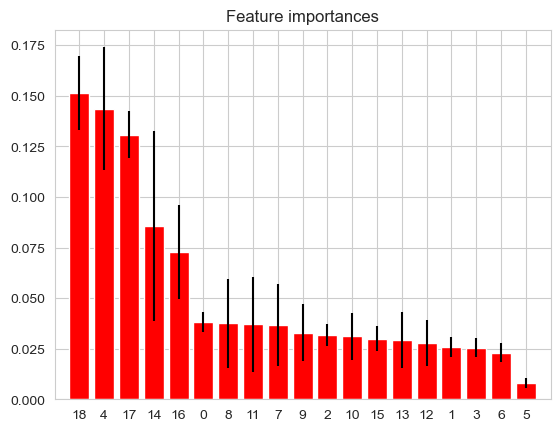

In [103]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
df = pd.DataFrame()
for i, j in zip( x_train_n, forest.feature_importances_ ):
    aux = pd.DataFrame( {'feature': i, 'importance': j}, index=[0] )
    df = pd.concat( [df, aux], axis=0 )
    
print( df.sort_values( 'importance', ascending=False ) )


plt.figure()
plt.title("Feature importances")
plt.bar(range(x_train_n.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
plt.xticks(range(x_train_n.shape[1]), indices)
plt.xlim([-1, x_train_n.shape[1]])
plt.show()

## 5.2 Seleção por Subset ( Boruta )

In [104]:
df4.isnull().sum()

customer_id            0
gender                 0
senior_citizen         0
partner                0
dependents             0
tenure                 0
phone_service          0
multiple_lines       555
internet_service       0
online_security        0
online_backup          0
device_protection      0
tech_support           0
streaming_tv           0
streaming_movies       0
contract               0
paperless_billing      0
payment_method         0
monthly_charges        0
total_charges          0
lf_value               0
churn                  0
dtype: int64

In [105]:
df4 = df4.fillna(3)

In [106]:
df4.isnull().sum()


customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
lf_value             0
churn                0
dtype: int64

In [107]:
# training and test dataset for Boruta
x_train_n = df4.drop(['customer_id','churn','lf_value'], axis=1 ).values
y_train_n = y_train.values.ravel()

# define RandomForestRegressor
et = en.ExtraTreesClassifier( n_jobs=-1 )

# define Boruta
boruta = BorutaPy( et, n_estimators='auto', verbose=0, random_state=42 ).fit(x_train_n, y_train_n )

In [108]:
cols_selected = boruta.support_.tolist()

# best features
x_train_fs = df4.drop( ['customer_id','churn','lf_value'], axis=1 )
cols_selected_boruta = x_train_fs.iloc[:, cols_selected].columns.to_list()

# not selected boruta
cols_not_selected_boruta = list( np.setdiff1d( x_train_fs.columns, cols_selected_boruta ) )

In [109]:
cols_selected_boruta

['tenure', 'contract', 'payment_method', 'monthly_charges', 'total_charges']

In [110]:
df4.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'lf_value',
       'churn'],
      dtype='object')

In [111]:
cols_selected = ['gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges']

# 6.0 Machine Learning Modelling

In [112]:
X = df4.drop('churn', axis=1)
y = df4['churn'].copy()

x_train, x_validation, y_train, y_validation = ms.train_test_split(X, y, test_size=0.10 )

df5 = pd.concat([x_train,y_train], axis=1)
df5.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,lf_value,churn
5376,9229-RQABD,0,0,0.328843,0,0.250000,1,1.0,3,3,...,3,3,3,0.115548,0,0.193009,23.75,424.50,0.055948,0
1806,8966-KZXXA,0,0,0.197517,1,0.500000,1,1.0,3,3,...,3,3,3,0.030125,0,0.148539,25.10,930.95,0.026962,0
6652,0827-ITJPH,0,0,0.328843,0,0.500000,1,0.0,3,3,...,3,3,3,0.030125,1,0.148539,18.55,689.00,0.026923,0
3621,2933-FILNV,1,0,0.197517,1,0.027778,0,3.0,1,0,...,0,0,0,0.425065,1,0.193009,24.40,36.55,0.667579,1
4125,2716-GFZOR,0,0,0.197517,0,0.597222,1,0.0,0,1,...,0,0,0,0.425065,1,0.148539,86.10,3551.65,0.024242,0


In [113]:
x_train = df5[cols_selected]

x_val = x_validation[ cols_selected ]
y_val = y_validation

## 6.1 KNN

In [114]:
# model definition
knn_model = nh.KNeighborsClassifier( n_neighbors=10 )

# model training
knn_model.fit( x_train, y_train )

# model prediction
yhat_knn = knn_model.predict( x_val )

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    balanced_accuracy_score
)

# métricas básicas
acc = accuracy_score(y_val, yhat_knn)
precision = precision_score(y_val, yhat_knn)
recall = recall_score(y_val, yhat_knn)
f1 = f1_score(y_val, yhat_knn)

# probabilidades
y_prob = knn_model.predict_proba(x_val)[:,1]
roc_auc = roc_auc_score(y_val, y_prob)

# matriz
cm = confusion_matrix(y_val, yhat_knn)

# balanced accuracy
bal_acc = balanced_accuracy_score(y_val, yhat_knn)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print('\nConfusion Matrix:\n', cm)

Accuracy: 0.7730
Precision: 0.5682
Recall: 0.3571
F1-Score: 0.4386
ROC AUC: 0.7550
Balanced Accuracy: 0.6338

Confusion Matrix:
 [[386  38]
 [ 90  50]]


## 6.2 Logistic Regression

In [116]:
# model definition
lr_model = LogisticRegression( n_jobs=-1 )

# model training
lr_model.fit( x_train, y_train )

# model prediction
yhat_lr = lr_model.predict( x_val )

In [117]:
# métricas básicas
acc = accuracy_score(y_val, yhat_lr)
precision = precision_score(y_val, yhat_lr)
recall = recall_score(y_val, yhat_lr)
f1 = f1_score(y_val, yhat_lr)

# probabilidades
y_prob = lr_model.predict_proba(x_val)[:,1]
roc_auc = roc_auc_score(y_val, y_prob)

# matriz
cm = confusion_matrix(y_val, yhat_lr)

# balanced accuracy
bal_acc = balanced_accuracy_score(y_val, yhat_lr)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print('\nConfusion Matrix:\n', cm)

Accuracy: 0.7996
Precision: 0.6421
Recall: 0.4357
F1-Score: 0.5191
ROC AUC: 0.8214
Balanced Accuracy: 0.6778

Confusion Matrix:
 [[390  34]
 [ 79  61]]


## 6.3 Random Forest

In [118]:
# model definition
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

# model training
rf_model.fit( x_train, y_train )

# model prediction
yhat_rf = rf_model.predict( x_val )

In [119]:
# métricas básicas
acc = accuracy_score(y_val, yhat_rf)
precision = precision_score(y_val, yhat_rf)
recall = recall_score(y_val, yhat_rf)
f1 = f1_score(y_val, yhat_rf)

# probabilidades
y_prob = rf_model.predict_proba(x_val)[:,1]
roc_auc = roc_auc_score(y_val, y_prob)

# matriz
cm = confusion_matrix(y_val, yhat_rf)

# balanced accuracy
bal_acc = balanced_accuracy_score(y_val, yhat_rf)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print('\nConfusion Matrix:\n', cm)

Accuracy: 0.8050
Precision: 0.6389
Recall: 0.4929
F1-Score: 0.5565
ROC AUC: 0.8568
Balanced Accuracy: 0.7004

Confusion Matrix:
 [[385  39]
 [ 71  69]]


# 7.0 Hyperparameter Fine Tuning

## 7.1 Ramdon Search

In [120]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline (ESSENCIAL pra Logistic)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

param_dist = [
    {
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs'],
        'model__max_iter': [100, 200, 500]
    },
    {
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'saga'],
        'model__max_iter': [100, 200, 500]
    },
    {
        'model__penalty': ['elasticnet'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['saga'],
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__max_iter': [200, 500]
    }
]

# Random Search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,  # pode aumentar depois
    scoring='roc_auc',  # melhor pra churn
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Treinar
random_search.fit(x_train, y_train)

# Resultados
print("Melhor score:", random_search.best_score_)
print("Melhores parâmetros:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhor score: 0.8423227723174349
Melhores parâmetros: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__max_iter': 100, 'model__C': 100}


## 7.2 Grid Search

In [121]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

param_grid = {
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs'],
    'model__C': [5, 8, 10, 12, 15],
    'model__max_iter': [200, 300, 500],
    'model__class_weight': [None, 'balanced']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Treino
grid_search.fit(x_train, y_train)

# Resultados
print("Melhor score:", grid_search.best_score_)
print("Melhores parâmetros:", grid_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhor score: 0.8422730872451926
Melhores parâmetros: {'model__C': 15, 'model__class_weight': None, 'model__max_iter': 200, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


# 8.0 Final Model

In [122]:
# model definition
lr_model = LogisticRegression(
                                solver='lbfgs',
                                penalty='l2',
                                C=8,
                                max_iter=200,
                                n_jobs=-1
)

# model training
lr_model.fit( x_train, y_train )

# model prediction
yhat_lr = lr_model.predict( x_val )

In [123]:
# métricas básicas
acc = accuracy_score(y_val, yhat_lr)
precision = precision_score(y_val, yhat_lr)
recall = recall_score(y_val, yhat_lr)
f1 = f1_score(y_val, yhat_lr)

# probabilidades
y_prob = lr_model.predict_proba(x_val)[:,1]
roc_auc = roc_auc_score(y_val, y_prob)

# matriz
cm = confusion_matrix(y_val, yhat_lr)

# balanced accuracy
bal_acc = balanced_accuracy_score(y_val, yhat_lr)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print('\nConfusion Matrix:\n', cm)

Accuracy: 0.8138
Precision: 0.6606
Recall: 0.5143
F1-Score: 0.5783
ROC AUC: 0.8495
Balanced Accuracy: 0.7135

Confusion Matrix:
 [[387  37]
 [ 68  72]]
